In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
from scipy.ndimage import binary_opening, binary_closing

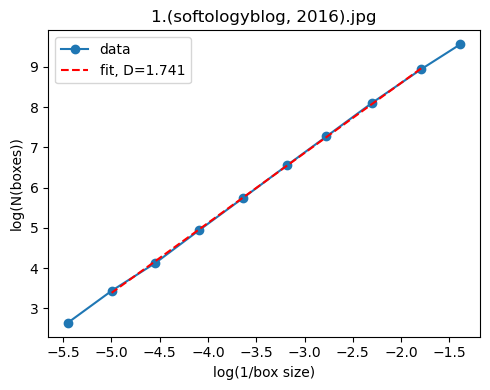

1.(softologyblog, 2016).jpg: D ≈ 1.7409906821010575


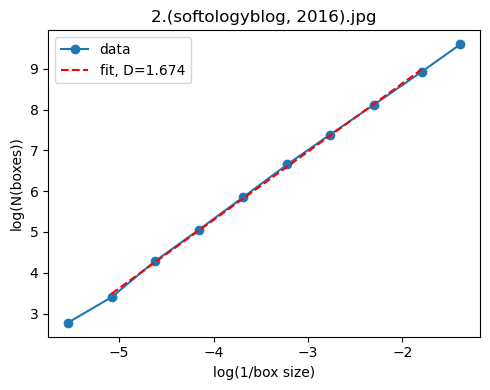

2.(softologyblog, 2016).jpg: D ≈ 1.6738120804279621


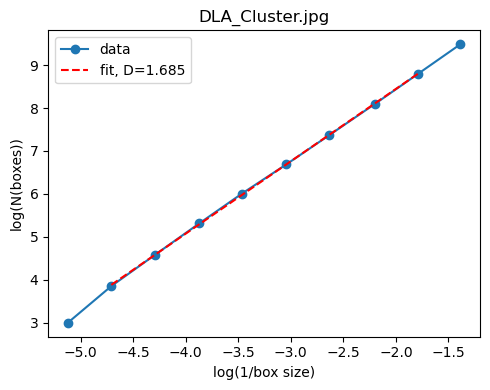

DLA_Cluster.jpg: D ≈ 1.6848235868406605


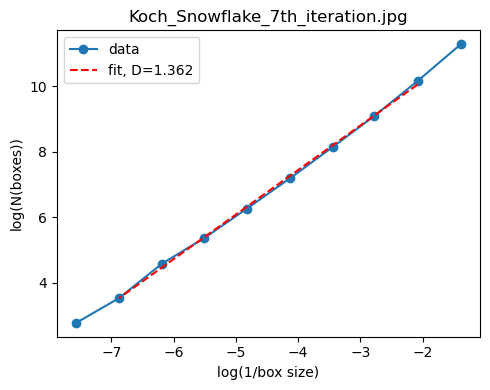

Koch_Snowflake_7th_iteration.jpg: D ≈ 1.3616278958785961


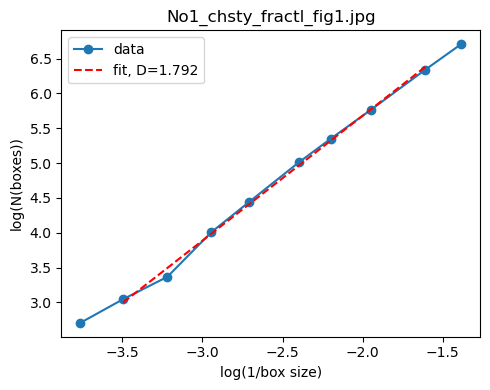

No1_chsty_fractl_fig1.jpg: D ≈ 1.7922469562397516


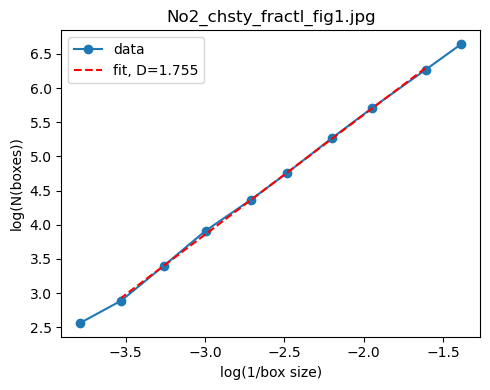

No2_chsty_fractl_fig1.jpg: D ≈ 1.7547413451352547


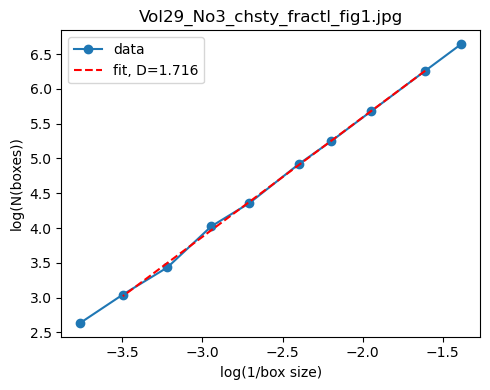

Vol29_No3_chsty_fractl_fig1.jpg: D ≈ 1.7162505289200236


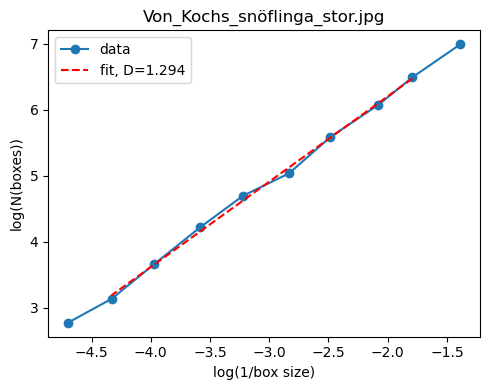

Von_Kochs_snöflinga_stor.jpg: D ≈ 1.2938360866967538


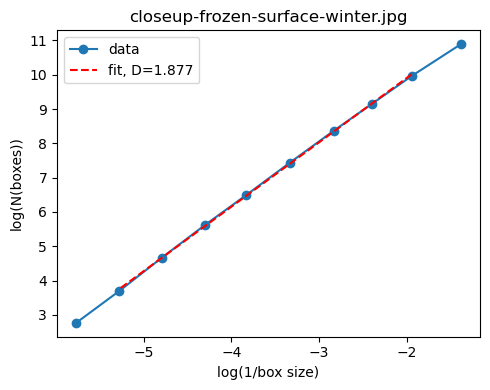

closeup-frozen-surface-winter.jpg: D ≈ 1.8769958240173898


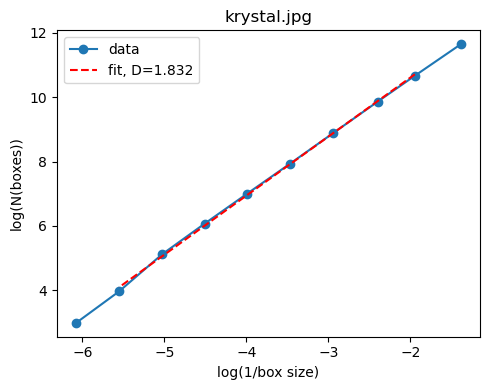

krystal.jpg: D ≈ 1.832216924445164


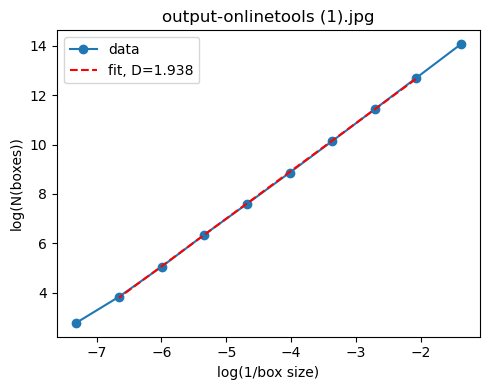

output-onlinetools (1).jpg: D ≈ 1.9378205051453914


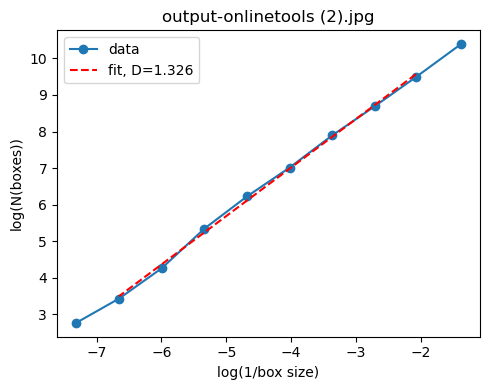

output-onlinetools (2).jpg: D ≈ 1.3262684565017804


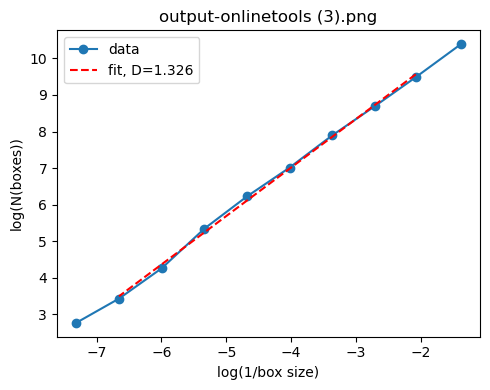

output-onlinetools (3).png: D ≈ 1.3262684565017804


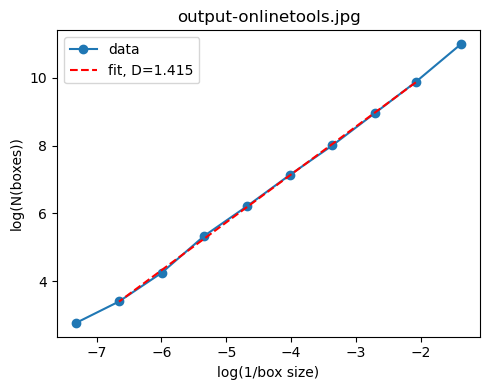

output-onlinetools.jpg: D ≈ 1.4148813493380374


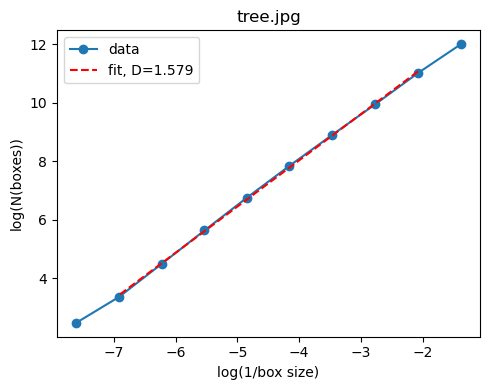

tree.jpg: D ≈ 1.5794054321826425


In [18]:

def boxcount(Z, k):
    ny, nx = Z.shape
    ny_c = (ny // k) * k
    nx_c = (nx // k) * k
    Zc = Z[:ny_c, :nx_c]
    S = np.add.reduceat(
            np.add.reduceat(Zc, np.arange(0, ny_c, k), axis=0),
            np.arange(0, nx_c, k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_image(filename, t=150, plot=True):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)
    Z = (I < t).astype(int)      # 1 = struktur (mørk), 0 = baggrund

    p = min(Z.shape)
    if p < 8:
        print("For lille billede:", filename)
        return None

    # vælg box-størrelser (geomspace giver flere skalaer)
    max_k = p // 4
    min_k = 4
    sizes = np.unique(
        np.round(np.geomspace(max_k, min_k, 10)).astype(int)
    )
    sizes = sizes[sizes > 1]

    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)
    valid = counts > 0
    if valid.sum() < 2:
        print("For få gyldige skalaer:", filename)
        return None

    sizes = sizes[valid]
    counts = counts[valid]

    x = np.log(1.0 / sizes)
    y = np.log(counts)

    # fit kun midterpunkter hvis der er mange
    if len(x) > 5:
        x_fit = x[1:-1]
        y_fit = y[1:-1]
    else:
        x_fit = x
        y_fit = y

    D, a = np.polyfit(x_fit, y_fit, 1)

    if plot:
        plt.figure(figsize=(5,4))
        plt.plot(x, y, 'o-', label='data')
        plt.plot(x_fit, a + D*x_fit, 'r--', label=f'fit, D={D:.3f}')
        plt.xlabel("log(1/box size)")
        plt.ylabel("log(N(boxes))")
        plt.legend()
        plt.title(filename)
        plt.tight_layout()
        plt.show()

    return D

# find alle billeder i mappen
extensions = ("*.jpg", "*.png", "*.jpeg")
files = sorted([f for ext in extensions for f in glob.glob(ext)])

for f in files:
    D = fractal_dimension_image(f, t=150, plot=True)
    print(f"{f}: D ≈ {D}")


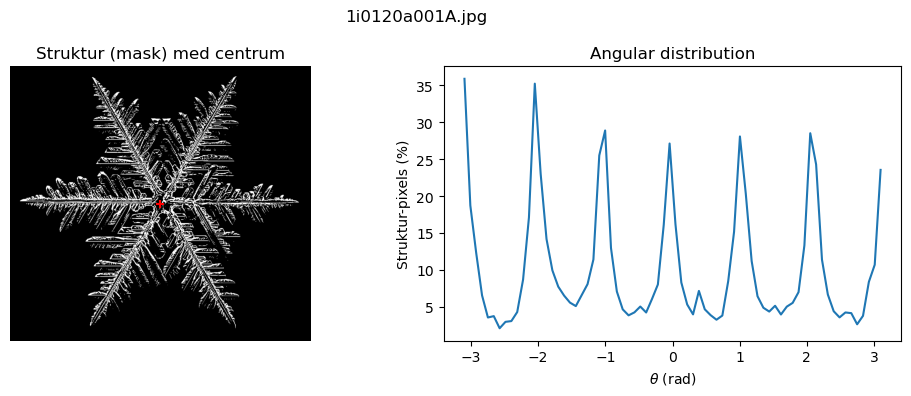

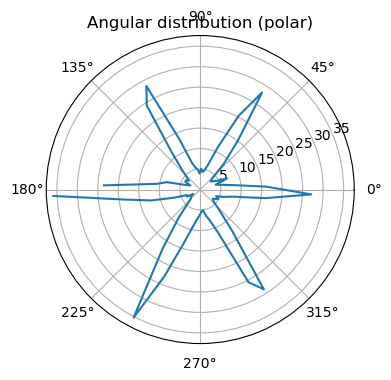

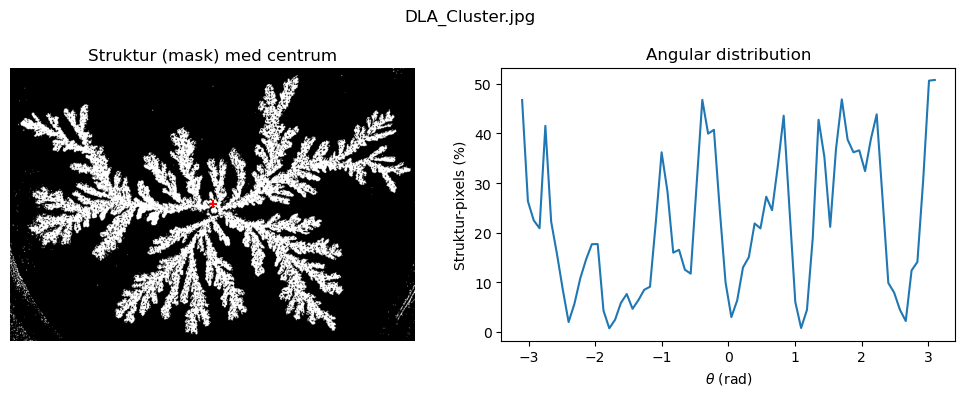

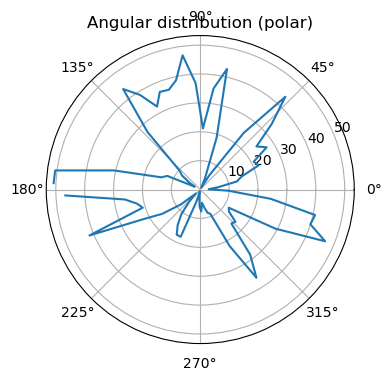

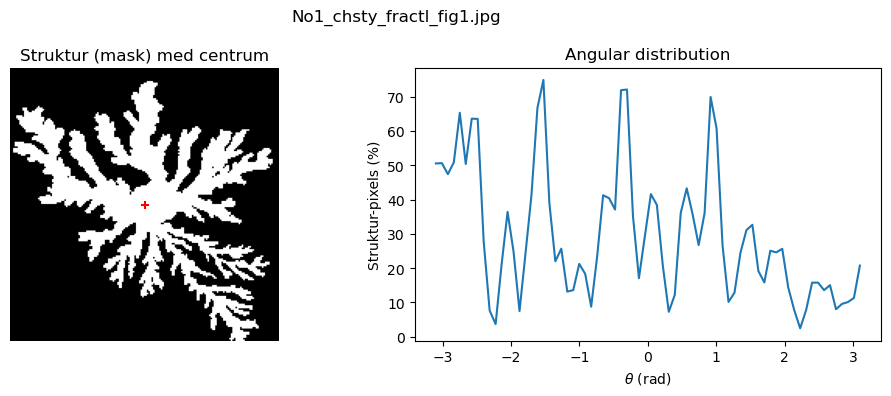

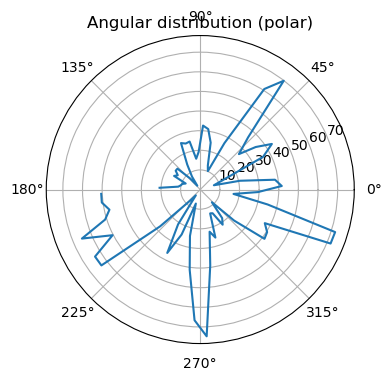

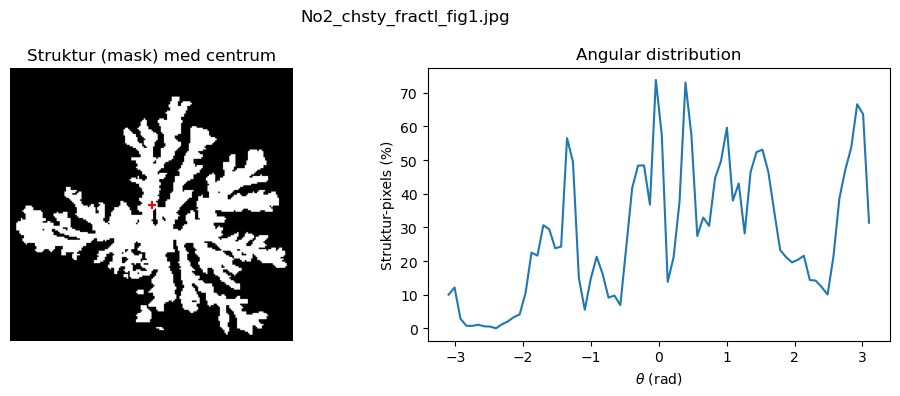

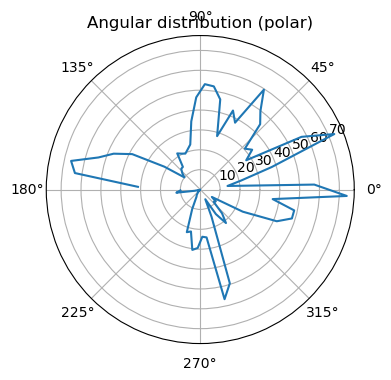

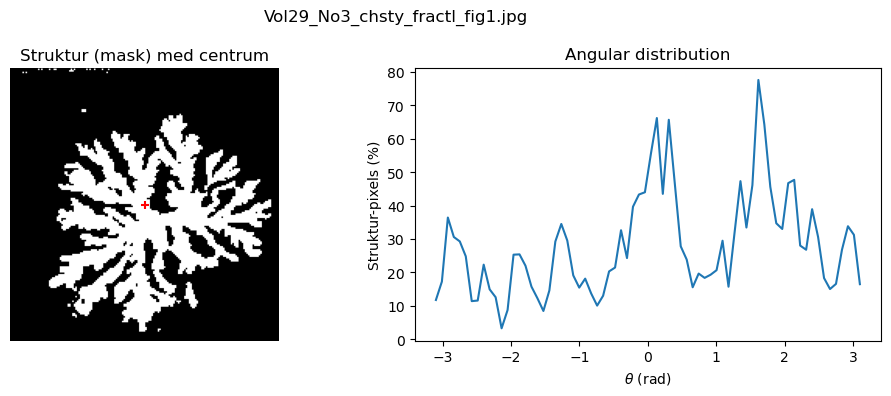

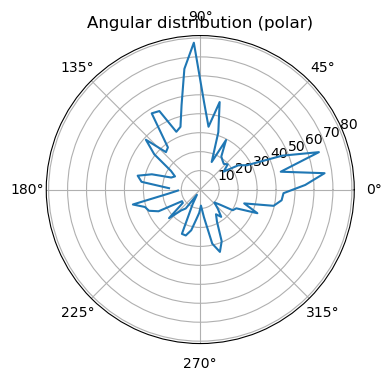

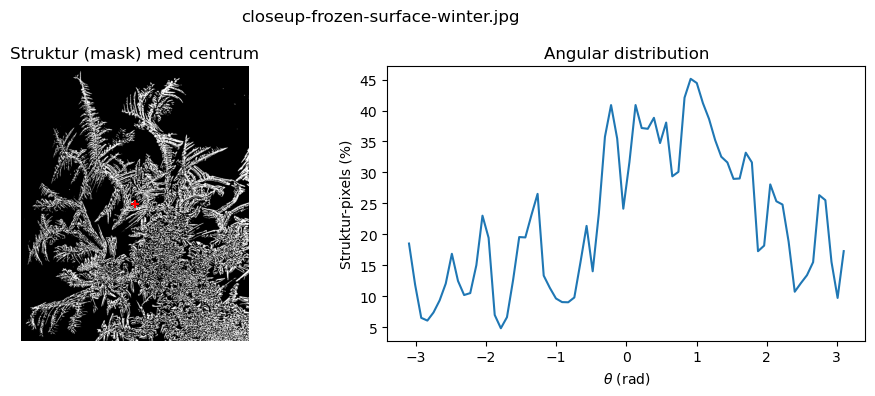

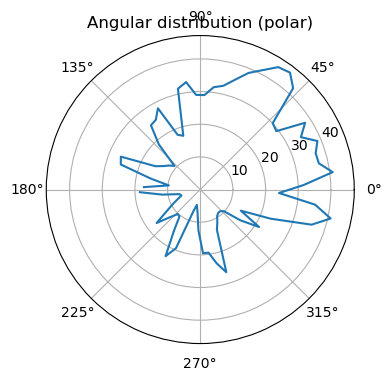

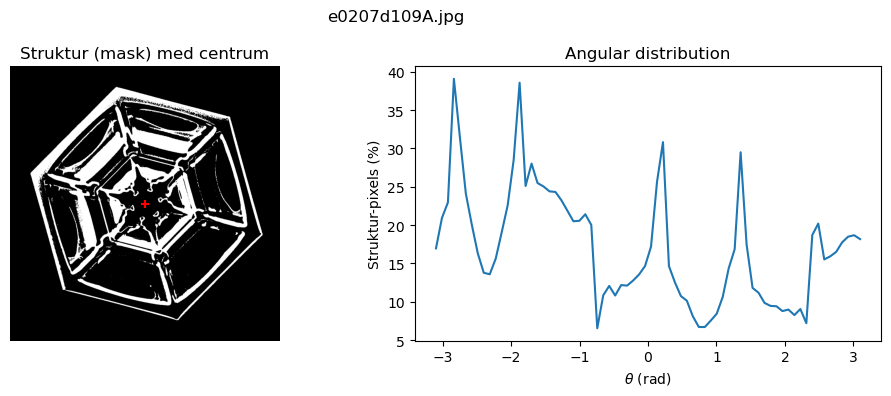

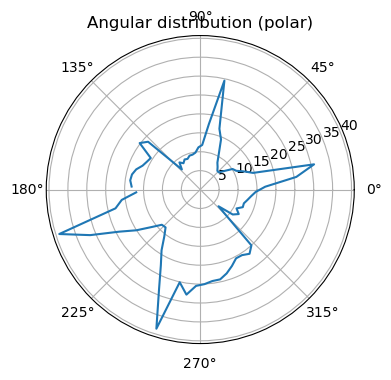

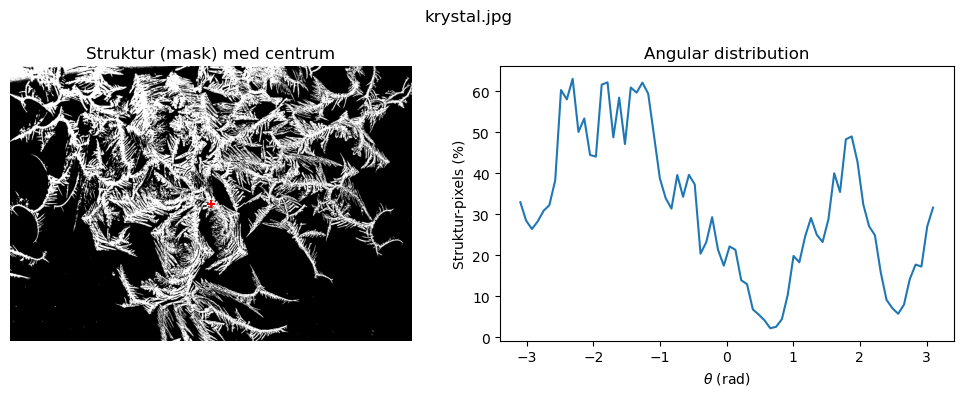

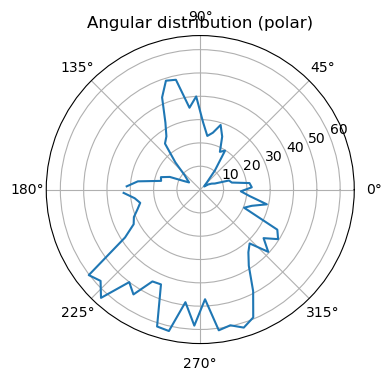

In [6]:
def angular_distribution(filename, t=150, nbins=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    # vinkel i [-pi, pi]
    theta = np.arctan2(y - cy, x - cx)

    # struktur = mørke pixels (samme idé som før)
    struct_mask = (I < t).astype(float)

    # histogram over vinkel
    bin_edges = np.linspace(-np.pi, np.pi, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    N_total, _ = np.histogram(theta, bins=bin_edges)                 # alle pixels
    N_struct, _ = np.histogram(theta, bins=bin_edges, weights=struct_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]    # procent

    return bin_centers, frac_struct, struct_mask, (cx, cy)


files = sorted(glob.glob("*.jpg"))

for f in files:
    th, frac_theta, mask, (cx, cy) = angular_distribution(f, t=150, nbins=72)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f)

    # billede / struktur + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Struktur (mask) med centrum")
    axs[0].axis("off")

    # vinkel-fordeling (kan også tegnes som polær)
    axs[1].plot(th, frac_theta)
    axs[1].set_xlabel(r"$\theta$ (rad)")
    axs[1].set_ylabel("Struktur-pixels (%)")
    axs[1].set_title("Angular distribution")

    plt.tight_layout()
    plt.show()

    # alternativ: polært plot
    plt.figure(figsize=(4,4))
    axp = plt.subplot(111, projection="polar")
    axp.plot(th, frac_theta)
    axp.set_title("Angular distribution (polar)")
    plt.show()

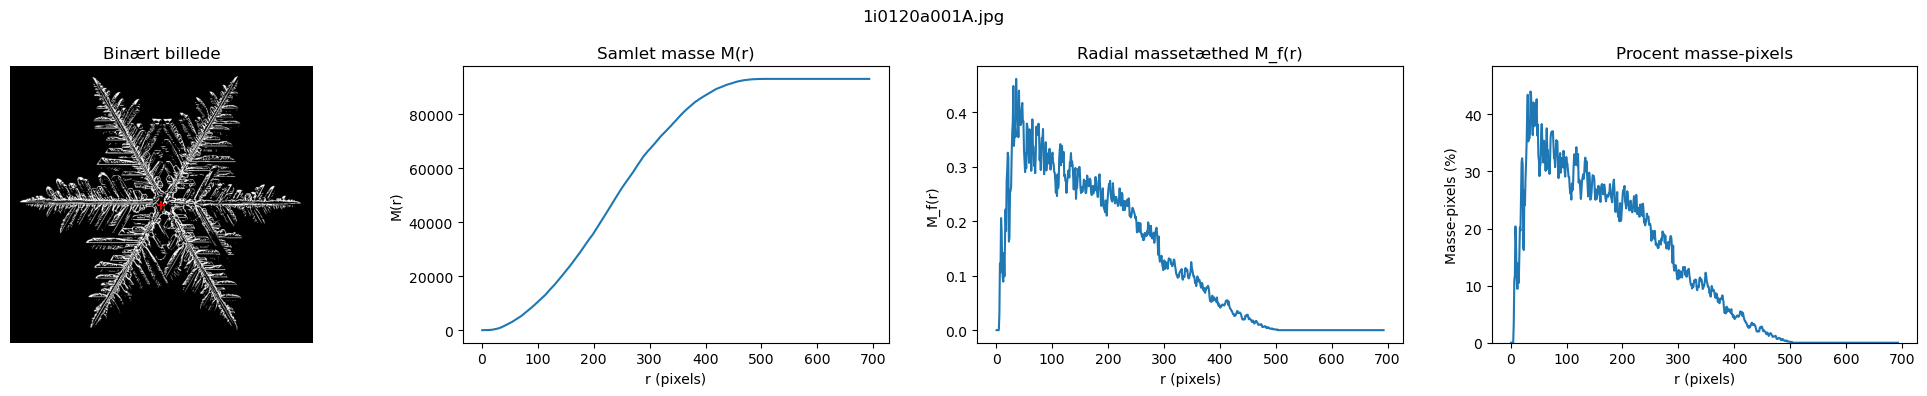

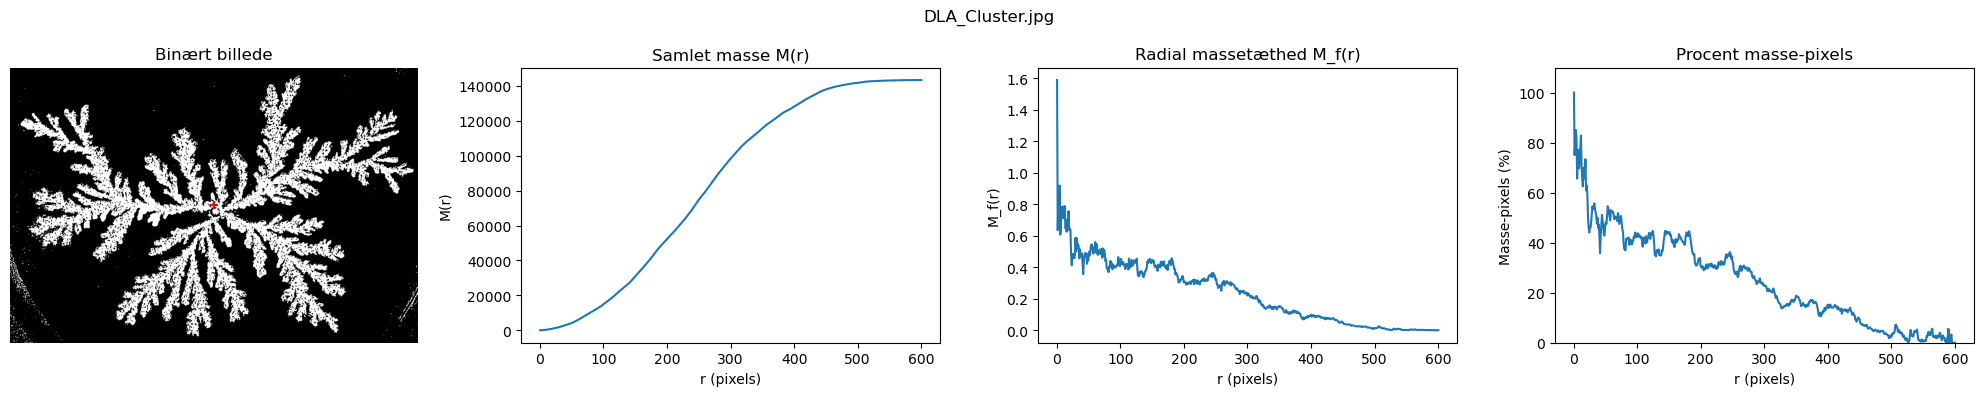

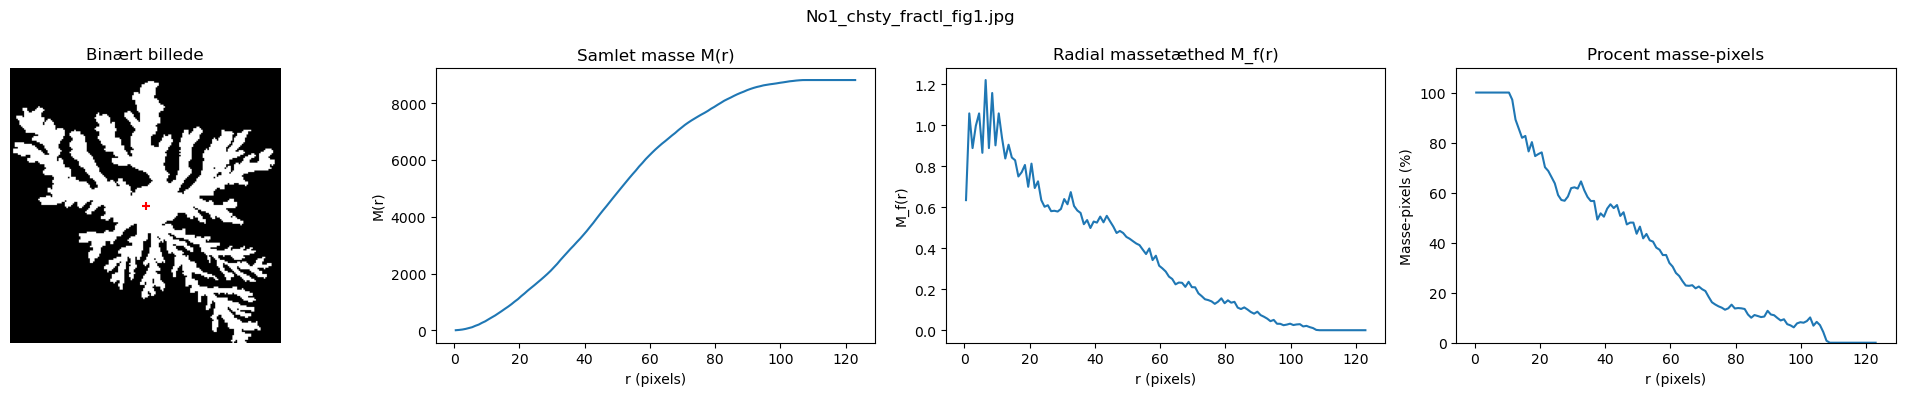

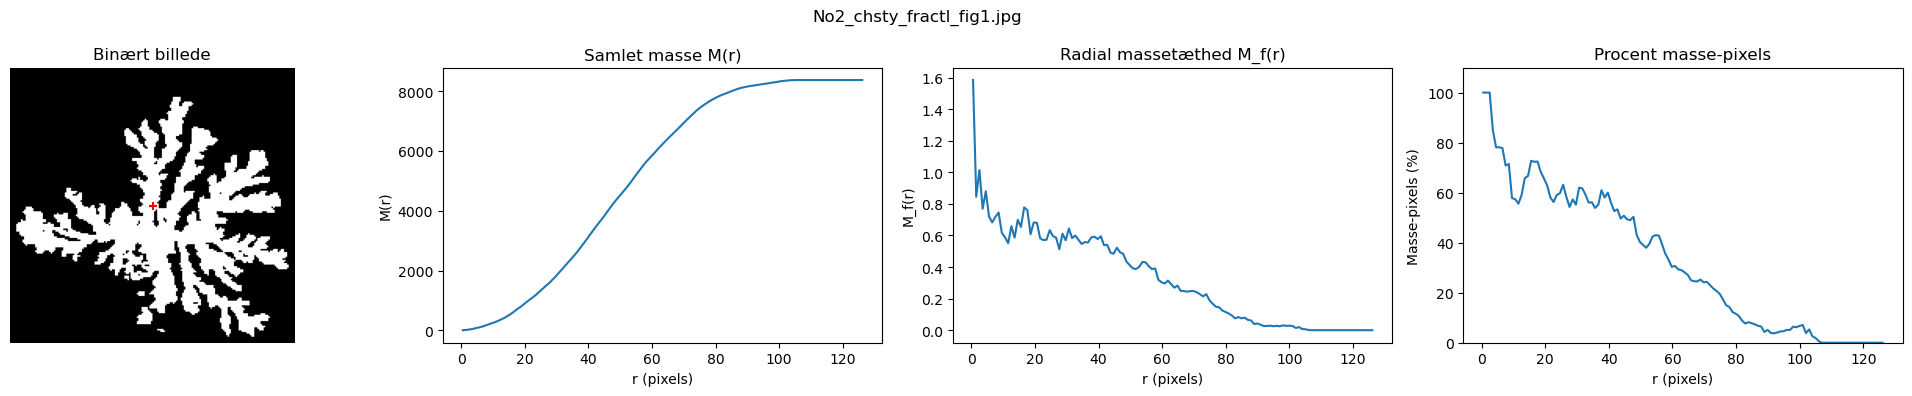

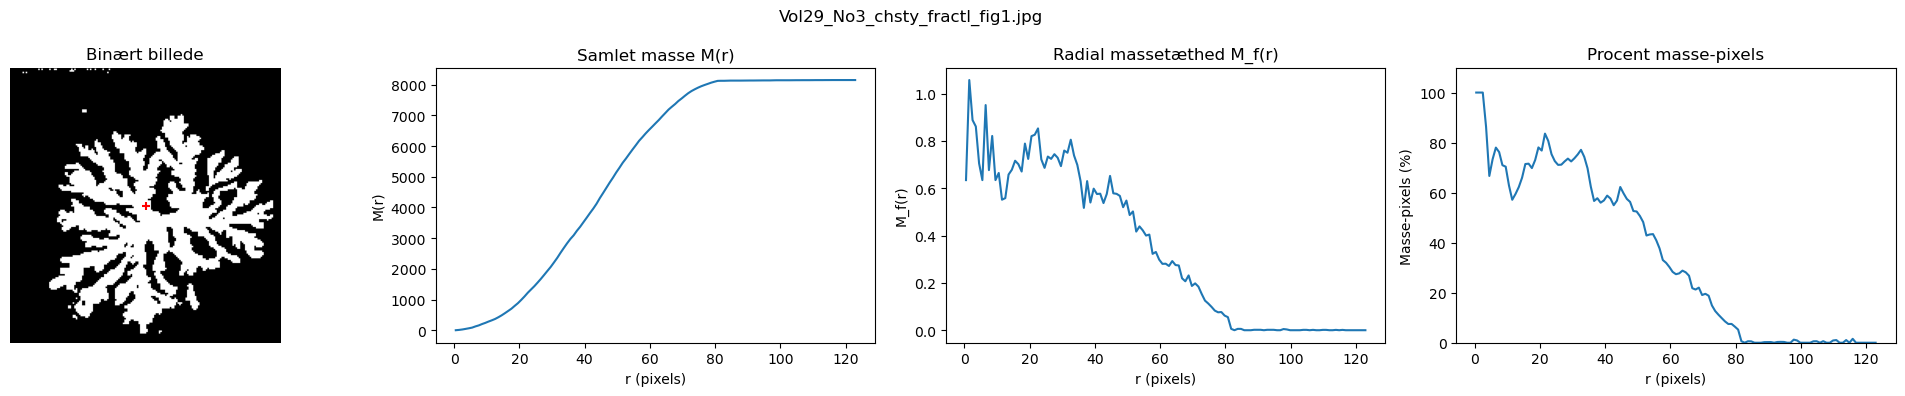

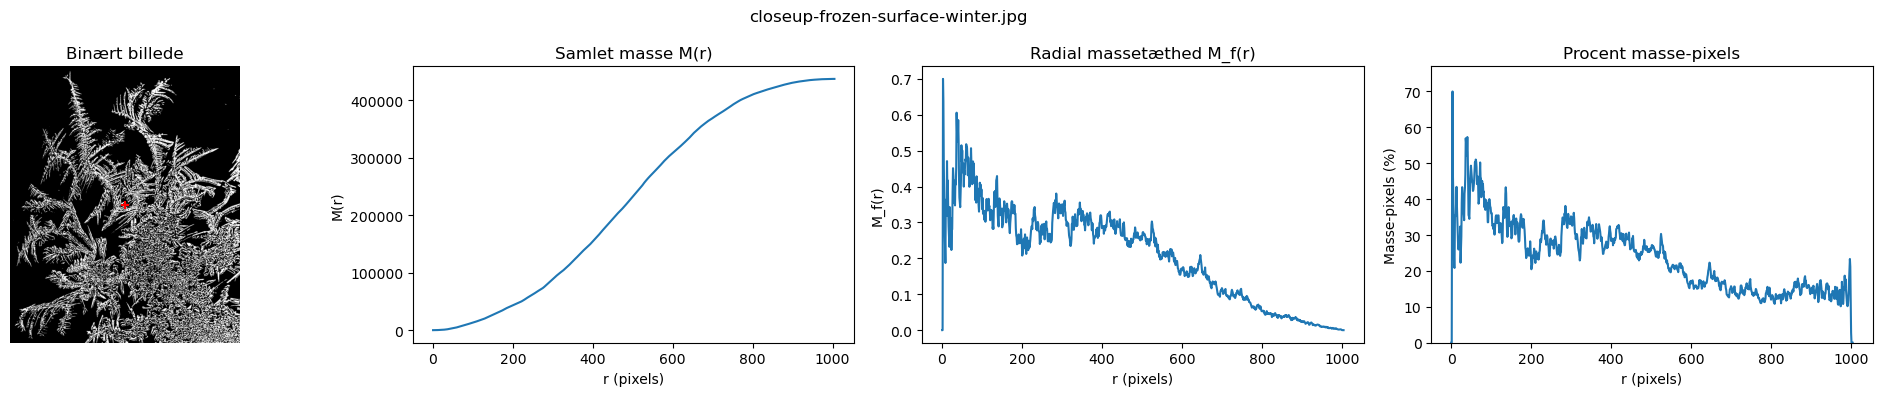

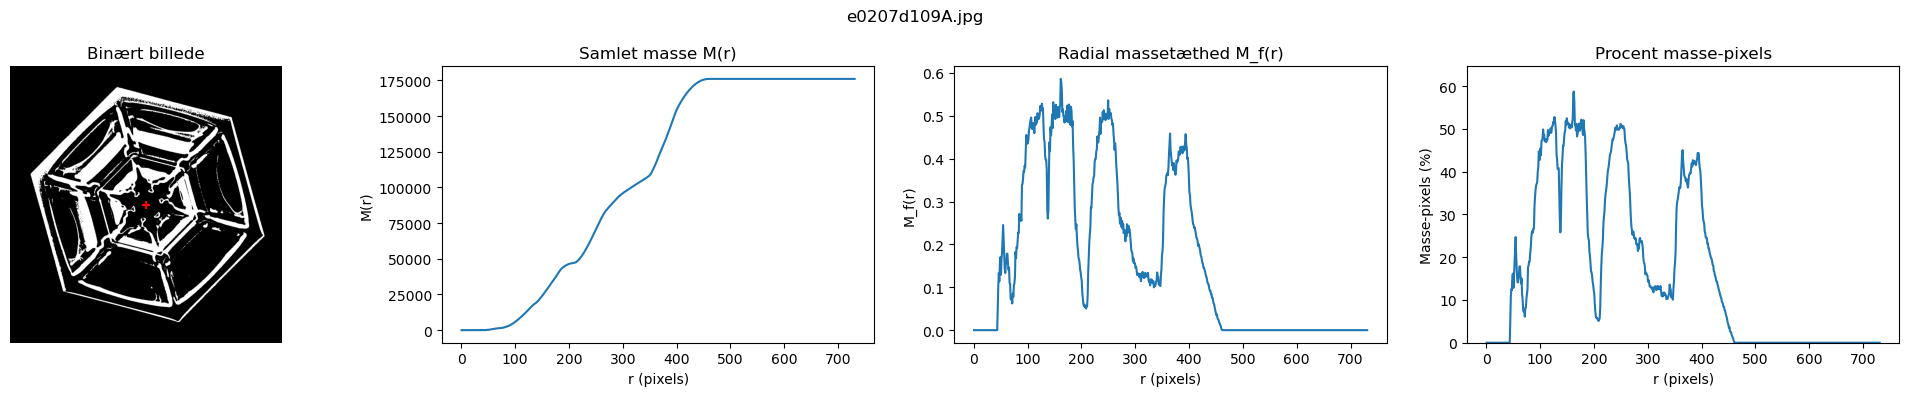

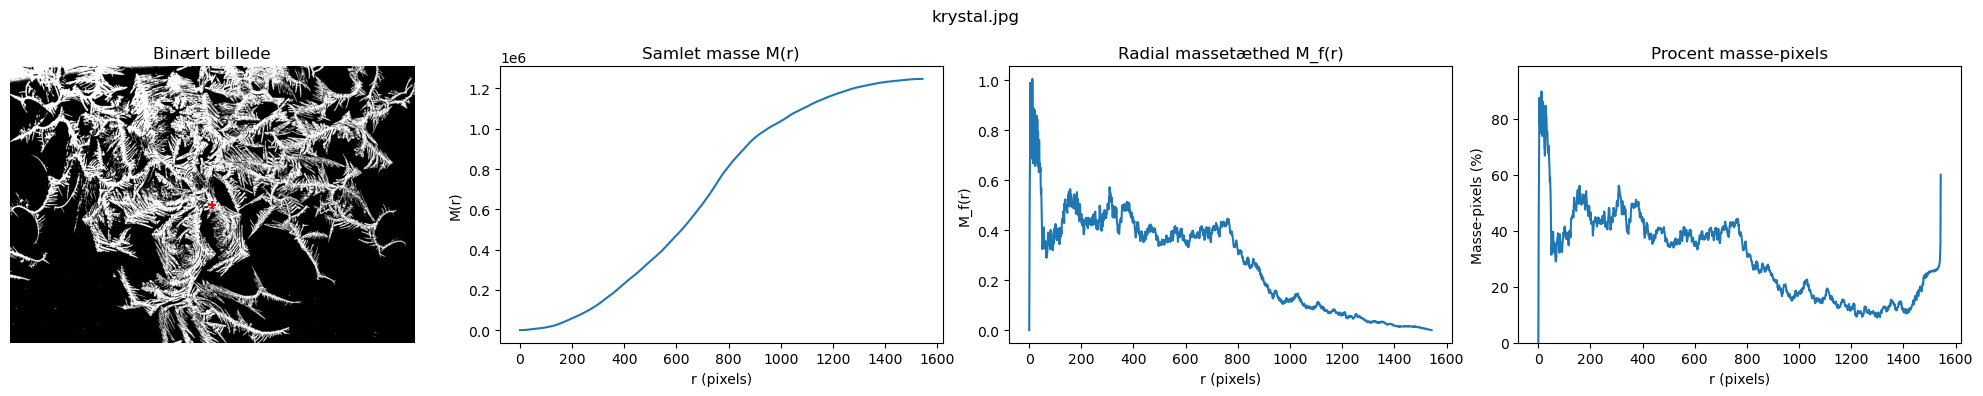

In [5]:


def radial_mass_and_color(filename, t=150, dr=1.0):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    r_max = r.max()
    nbins = int(r_max // dr)
    bin_edges = np.linspace(0, r_max, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # struktur = mørke pixels (I < t)
    structure_mask = (I < t).astype(float)   # 1 = DLA, 0 = baggrund

    # brug den både som "masse" og til procent
    deltaM, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)
    M = np.cumsum(deltaM)
    Mf = deltaM / (2 * np.pi * bin_centers * dr)

    N_total, _ = np.histogram(r, bins=bin_edges)
    N_struct, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]

    return bin_centers, M, Mf, structure_mask, cx, cy, frac_struct



# vælg alle .jpg billeder i mappen
files = sorted(glob.glob("*.jpg"))

for f in files:
    r, M, Mf, mask, cx, cy, frac_color = radial_mass_and_color(f, t=150, dr=1.0)

    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f)

    # 1) binært billede + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Binært billede")
    axs[0].axis("off")

    # 2) M(r)
    axs[1].plot(r, M)
    axs[1].set_xlabel("r (pixels)")
    axs[1].set_ylabel("M(r)")
    axs[1].set_title("Samlet masse M(r)")

    # 3) M_f(r)
    axs[2].plot(r, Mf)
    axs[2].set_xlabel("r (pixels)")
    axs[2].set_ylabel("M_f(r)")
    axs[2].set_title("Radial massetæthed M_f(r)")

    # 4) procent farvede pixels

    axs[3].plot(r, frac_color)
    axs[3].set_xlabel("r (pixels)")
    axs[3].set_ylabel("Masse-pixels (%)")
    axs[3].set_ylim(0, 1.1 * frac_color.max())
    axs[3].set_title("Procent masse-pixels")

    plt.tight_layout()
    plt.show()




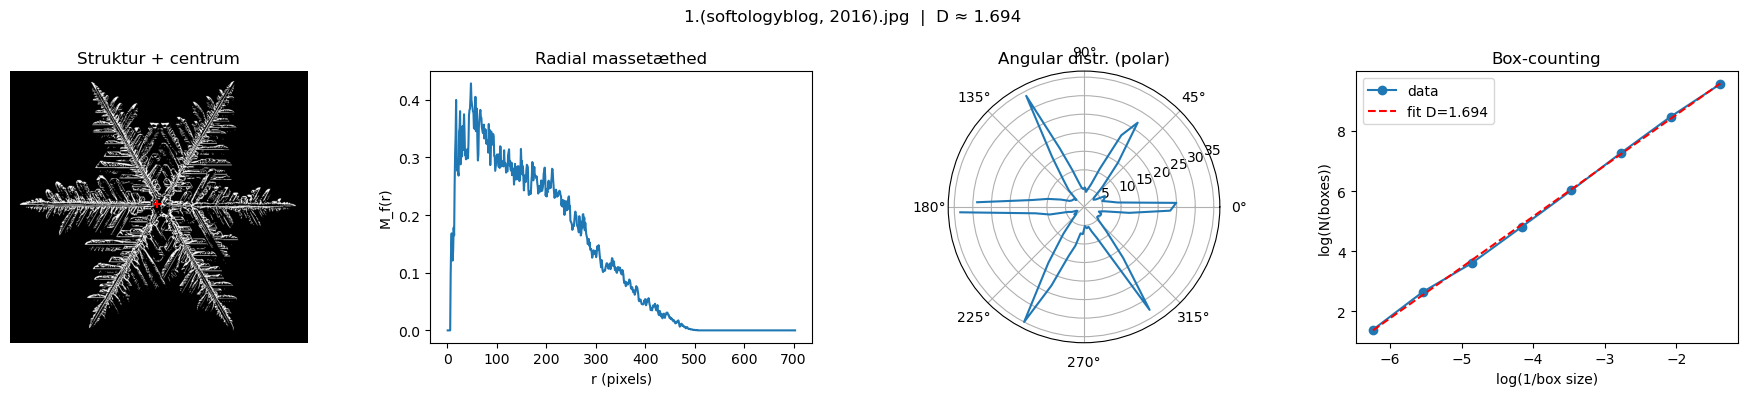

1.(softologyblog, 2016).jpg: D ≈ 1.694


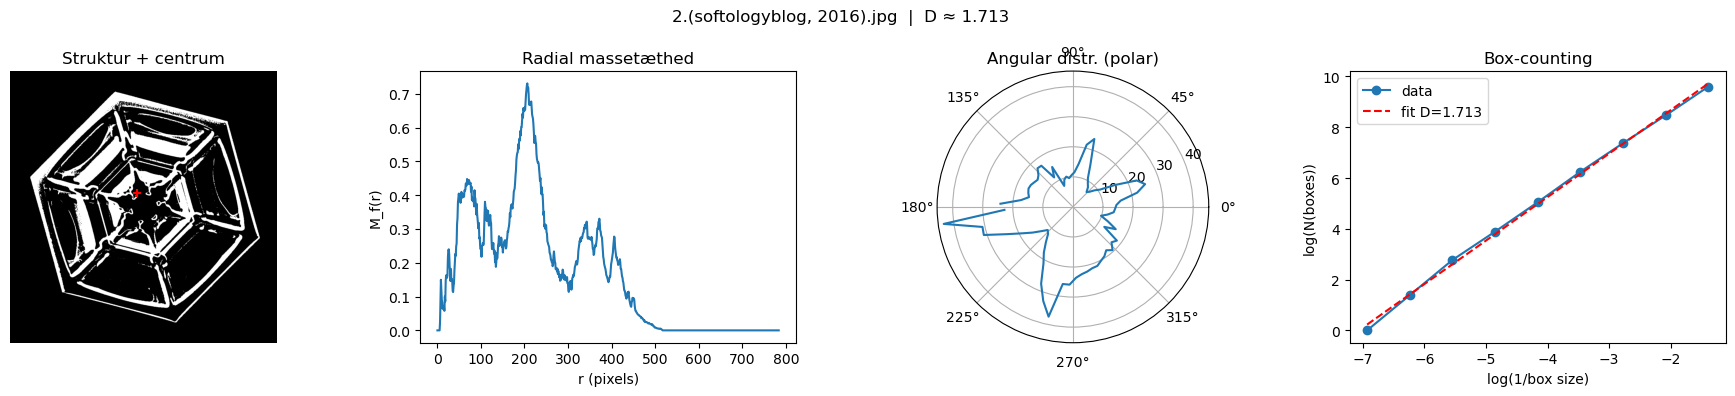

2.(softologyblog, 2016).jpg: D ≈ 1.713


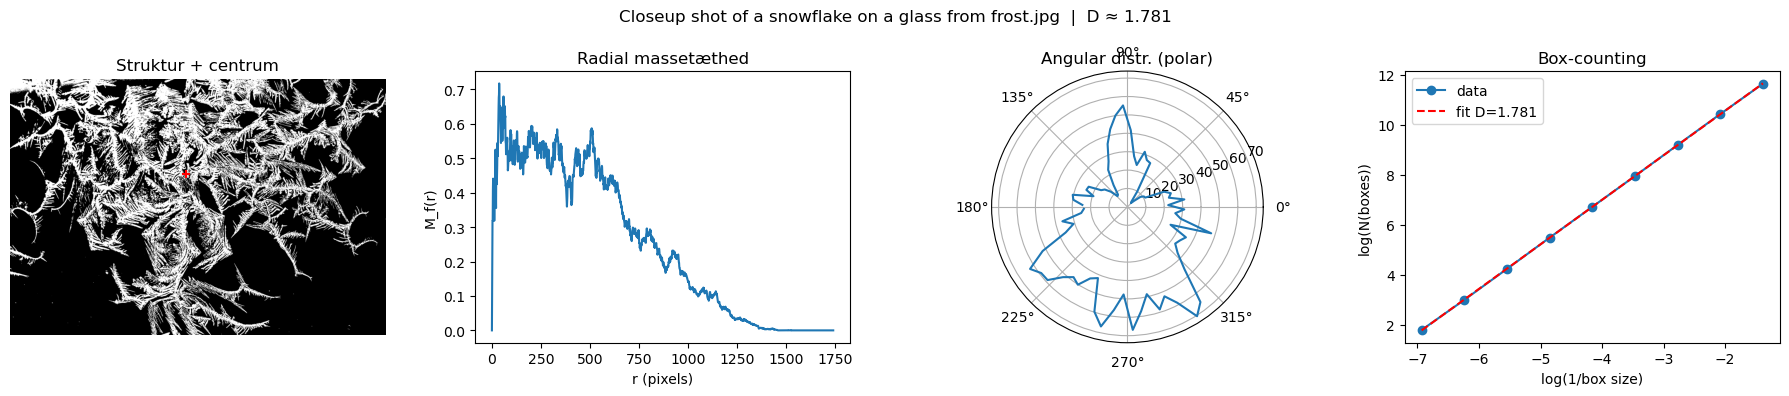

Closeup shot of a snowflake on a glass from frost.jpg: D ≈ 1.781


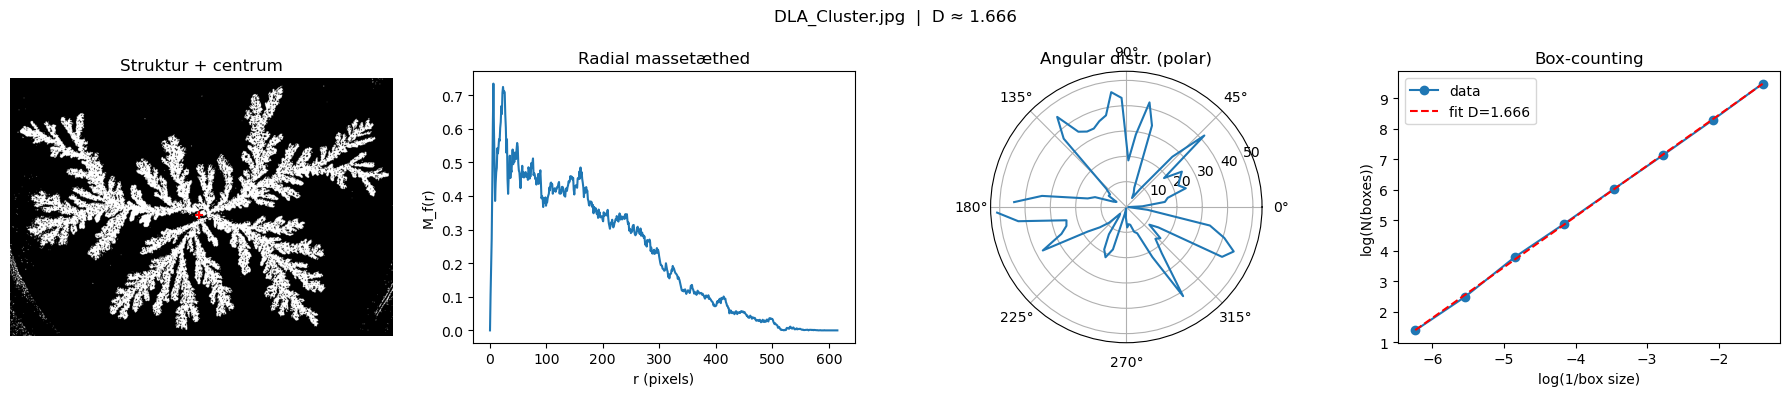

DLA_Cluster.jpg: D ≈ 1.666


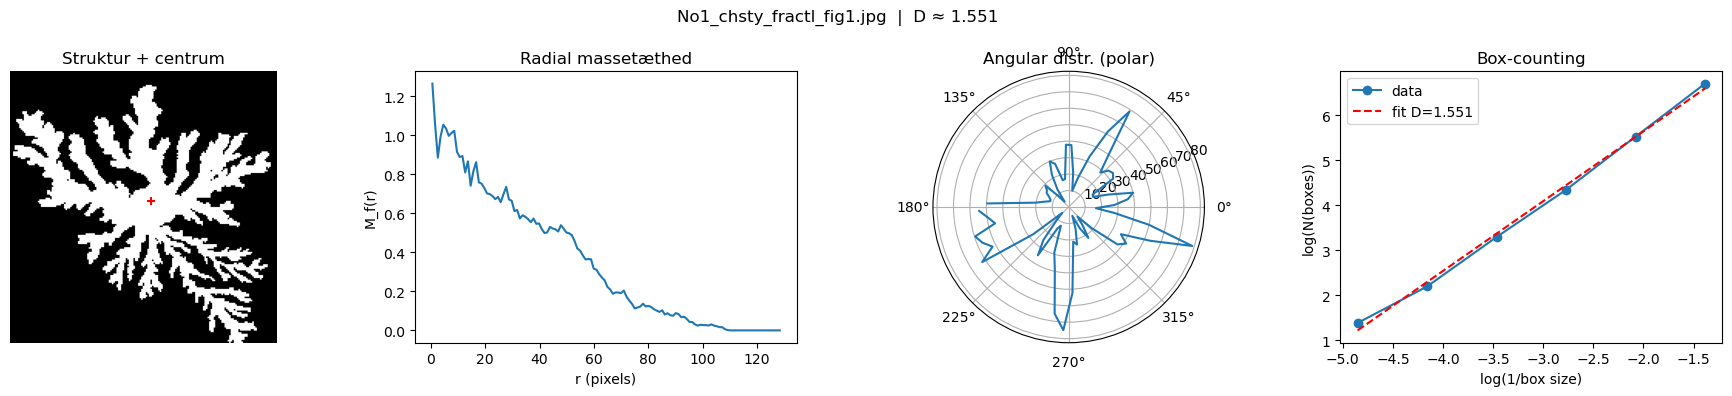

No1_chsty_fractl_fig1.jpg: D ≈ 1.551


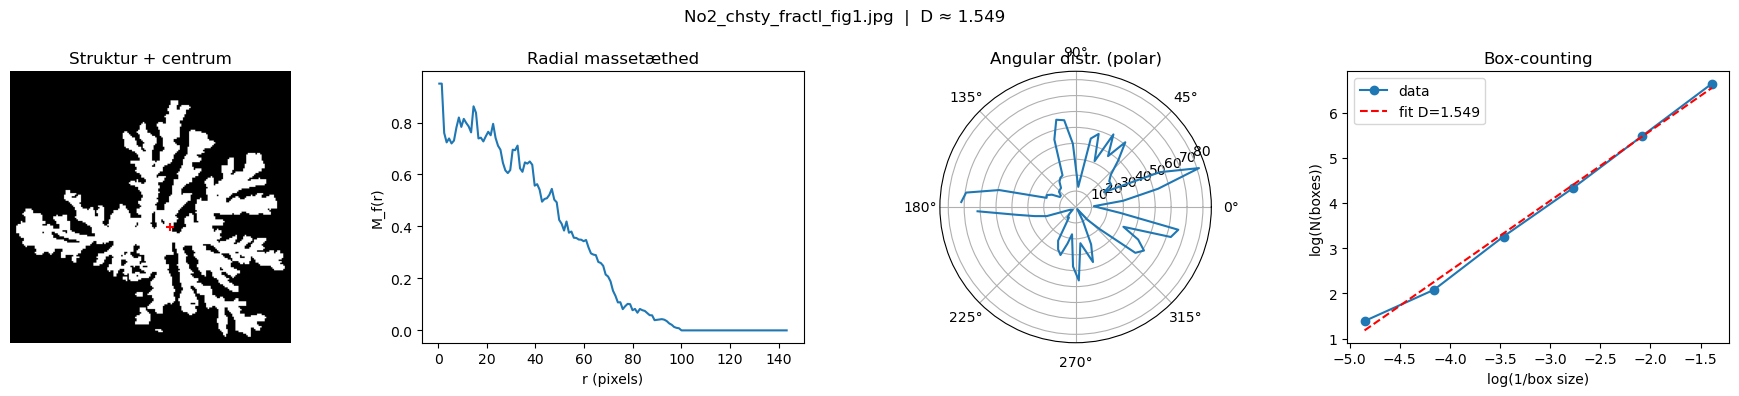

No2_chsty_fractl_fig1.jpg: D ≈ 1.549


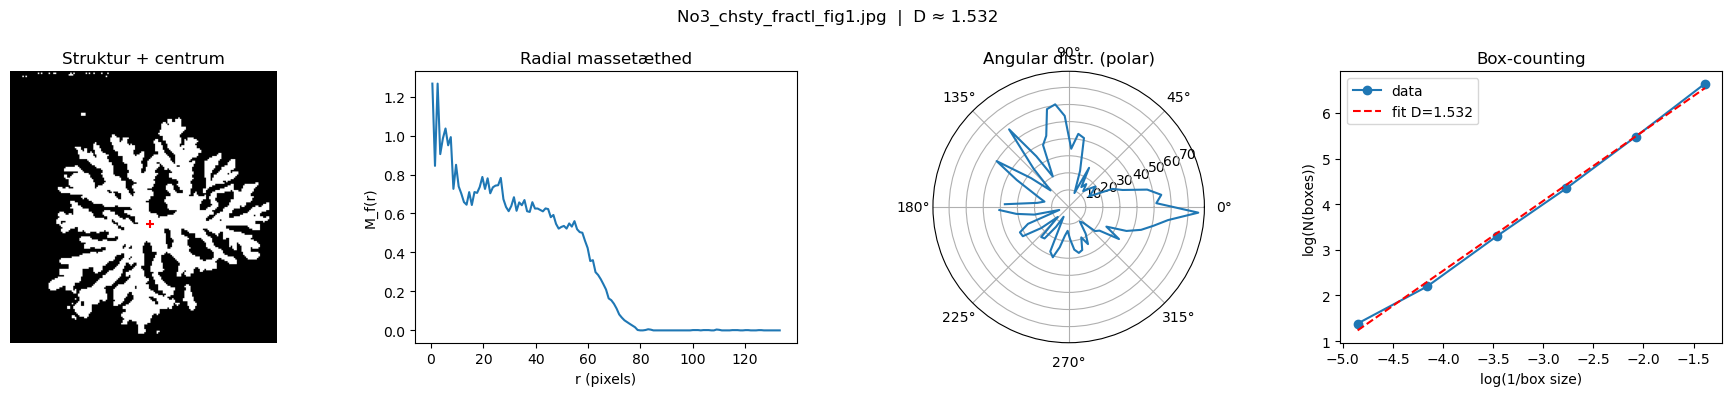

No3_chsty_fractl_fig1.jpg: D ≈ 1.532


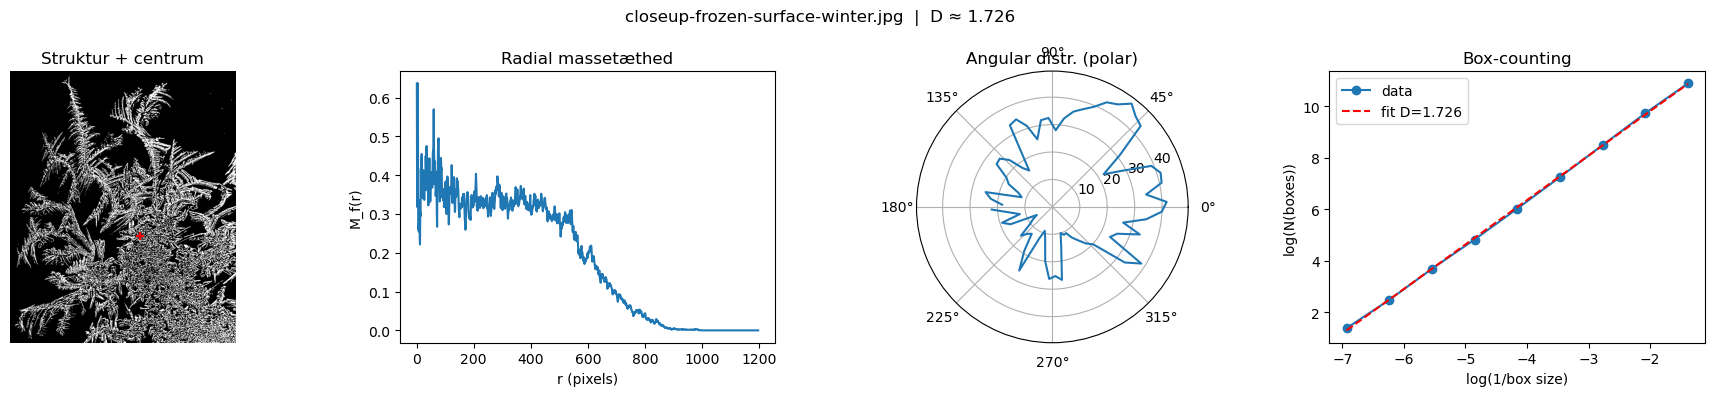

closeup-frozen-surface-winter.jpg: D ≈ 1.726


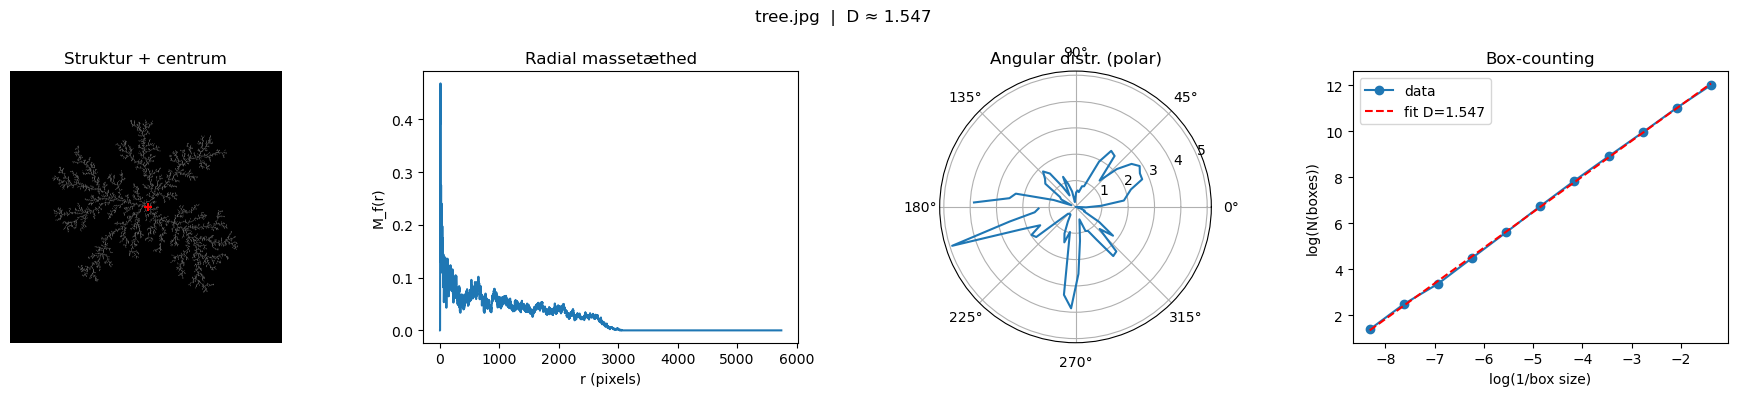

tree.jpg: D ≈ 1.547


In [26]:


# ---------- boxcount + fraktal-dimension ----------

def boxcount(Z, k):
    S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_from_mask(Z):
    p = min(Z.shape)
    n = int(np.floor(np.log2(p)))
    sizes = 2**np.arange(n, 1, -1)
    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)

    x = np.log(1.0 / sizes)
    y = np.log(counts)
    D, a = np.polyfit(x, y, 1)
    return D, x, y, a

# ---------- hovedanalyse for ét billede ----------

def analyse_billede(filename, t=150, dr=1.0, nbins_theta=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    # struktur = mørke pixels
    struct_mask = (I < t).astype(float)

    ny, nx = struct_mask.shape
    y, x = np.indices((ny, nx))

    M_tot = struct_mask.sum()
    cx = (struct_mask * x).sum() / M_tot
    cy = (struct_mask * y).sum() / M_tot

    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    theta = np.arctan2(y - cy, x - cx)


    # struktur = mørke pixels
    struct_mask = (I < t).astype(float)

    # ----- radial M_f(r) -----
    r_max = r.max()
    nbins_r = int(r_max // dr)
    bin_edges_r = np.linspace(0, r_max, nbins_r + 1)
    r_centers = 0.5 * (bin_edges_r[:-1] + bin_edges_r[1:])
    deltaM, _ = np.histogram(r, bins=bin_edges_r, weights=struct_mask)
    Mf = deltaM / (2 * np.pi * r_centers * dr)

    # ----- angular distribution -----
    bin_edges_th = np.linspace(-np.pi, np.pi, nbins_theta + 1)
    th_centers = 0.5 * (bin_edges_th[:-1] + bin_edges_th[1:])
    N_tot_th, _ = np.histogram(theta, bins=bin_edges_th)
    N_struct_th, _ = np.histogram(theta, bins=bin_edges_th, weights=struct_mask)
    frac_theta = np.zeros_like(th_centers)
    valid_th = N_tot_th > 0
    frac_theta[valid_th] = 100.0 * N_struct_th[valid_th] / N_tot_th[valid_th]

    # ----- fraktal-dimension -----
    Z = (struct_mask > 0).astype(int)
    D, x_log, y_log, a = fractal_dimension_from_mask(Z)

    # ----- samlet figur med 4 akser (ingen huller) -----
    fig = plt.figure(figsize=(18, 4))
    fig.suptitle(f"{filename}  |  D ≈ {D:.3f}")

    # 1) struktur + centrum
    ax1 = plt.subplot(1, 4, 1)
    ax1.imshow(struct_mask, cmap="gray")
    ax1.scatter([cx], [cy], c="red", s=40, marker="+")
    ax1.set_title("Struktur + centrum")
    ax1.axis("off")

    # 2) M_f(r)
    ax2 = plt.subplot(1, 4, 2)
    ax2.plot(r_centers, Mf)
    ax2.set_xlabel("r (pixels)")
    ax2.set_ylabel("M_f(r)")
    ax2.set_title("Radial massetæthed")

    # 3) angular (polar)
    ax3 = plt.subplot(1, 4, 3, projection="polar")
    ax3.plot(th_centers, frac_theta)
    ax3.set_title("Angular distr. (polar)")

    # 4) box-counting
    ax4 = plt.subplot(1, 4, 4)
    ax4.plot(x_log, y_log, "o-", label="data")
    ax4.plot(x_log, a + D * x_log, "r--", label=f"fit D={D:.3f}")
    ax4.set_xlabel("log(1/box size)")
    ax4.set_ylabel("log(N(boxes))")
    ax4.set_title("Box-counting")
    ax4.legend()

    plt.tight_layout()
    plt.show()

    return D

# ---------- kør for alle billeder i mappen ----------

files = sorted(glob.glob("*.jpg"))
for f in files:
    D = analyse_billede(f, t=150, dr=1.0, nbins_theta=72)
    print(f"{f}: D ≈ {D:.3f}")
